### Fast Correlation Workflow

#### 1. Setup & Imports

In [1]:
import os, sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

# Let notebook import src/
sys.path.append("..")

from src.utils import load_data
from src.ani import (
    preprocess,
    choose_block_size_v2,
    cross_correlation_v1_real,
)

In [ ]:
np.set_printoptions(precision=3, suppress=True)
torch.set_printoptions(precision=3, sci_mode=False)

#### 2. Point to quick-test files

In [2]:
data_dir = Path("../data/preprocessed/20210901")
files = [
    data_dir / "20210901_000000.npz",
    data_dir / "20210901_001000.npz",
]
for f in files:
    print(f, f.exists())

../data/preprocessed/20210901/20210901_000000.npz True
../data/preprocessed/20210901/20210901_001000.npz True


#### 3. Load one file and inspect shapes

In [3]:
in_path = files[0]

meta, data_raw, dt, N, T = load_data(in_path, mmap=True)
print("dt:", dt, "N:", N, "T:", T)
print("data_raw shape:", data_raw.shape, "dtype:", data_raw.dtype)

nch, npts = data_raw.shape

dt: 0.004 N: 157500 T: 630.0
data_raw shape: (350, 157500) dtype: float32


#### 4. Preprocess data (bandpass, detrend, RAM/one-bit, etc.)

In [5]:
# Config parameters
fs_raw = 250.0
decimation = 1
f1, f2 = 1.0, 10.0
diff = False
ram_win_sec = 0.0

# Preprocess data
data_proc = preprocess(
    data_raw,
    fs_raw=fs_raw,
    f1=f1,
    f2=f2,
    decimation=decimation,
    diff=diff,
    ram_win=ram_win_sec,
).astype(np.float32, copy=False)

fs_proc = fs_raw / decimation
print("data_proc:", data_proc.shape, data_proc.dtype, "fs_proc:", fs_proc)

data_proc: (350, 157500) float32 fs_proc: 250.0


#### 4. Segment into windows

In [ ]:
xcorr_seg_sec = 60.0
npts_seg = int(round(xcorr_seg_sec * fs_proc))

npts_proc = data_proc.shape[1]
npts_new = (npts_proc // npts_seg) * npts_seg
nseg = npts_new // npts_seg
leftover = npts_proc - npts_new

print("npts_seg:", npts_seg)
print("npts_proc:", npts_proc, "npts_new:", npts_new, "nseg:", nseg, "leftover:", leftover)

data_proc = data_proc[:, :npts_new]  

npts_seg: 15000
npts_proc: 157500 npts_new: 150000 nseg: 10 leftover: 7500


In [7]:
x_seg = data_proc.reshape(nch, nseg, npts_seg)
print("x_seg shape:", x_seg.shape)  # (nch, nseg, npts_seg)

x_seg shape: (350, 10, 15000)


#### 5. Choose a single source-receiver pair and a single segment

In [9]:
src_idx = 0
rcv_idx = min(10, nch-1)
seg_idx = 0

x = x_seg[src_idx, seg_idx, :]   # (npts_seg,)
y = x_seg[rcv_idx, seg_idx, :]   # (npts_seg,)

print("x shape:", x.shape, "y shape:", y.shape)

x shape: (15000,) y shape: (15000,)


#### 6. Define short-lag target (M) and compare “naive definition” vs v1

In [11]:
max_lag_sec = 2.0
M = int(round(max_lag_sec * fs_proc))
print("M (samples):", M)

M (samples): 500


##### 6.1 Naive short-lag correlation (definition check)

In [12]:
def naive_short_lag_cc(x: np.ndarray, y: np.ndarray, M: int) -> np.ndarray:
    N = x.size
    out = np.zeros(2*M+1, dtype=np.float32)
    lags = np.arange(-M, M+1)
    for i, m in enumerate(lags):
        s = 0.0
        for n in range(N):
            xn = n + m
            if 0 <= xn < N:
                s += x[xn] * y[n]
        out[i] = s
    return out

cc_naive = naive_short_lag_cc(x, y, M)
print("cc_naive shape:", cc_naive.shape)

cc_naive shape: (1001,)


##### 6.2 v1 output for the same pair (one segment)

In [13]:
xt = torch.from_numpy(x[None, :]).to(torch.float32)  # (B=1, N)
yt = torch.from_numpy(y[None, :]).to(torch.float32)

cc_v1 = cross_correlation_v1_real(
    xt,
    yt,
    max_lag_samples=M,
    is_spectral_whitening=False,
).cpu().numpy().squeeze()

print("cc_v1 shape:", cc_v1.shape)

cc_v1 shape: (1001,)


max|v1 - naive| = 1304.0


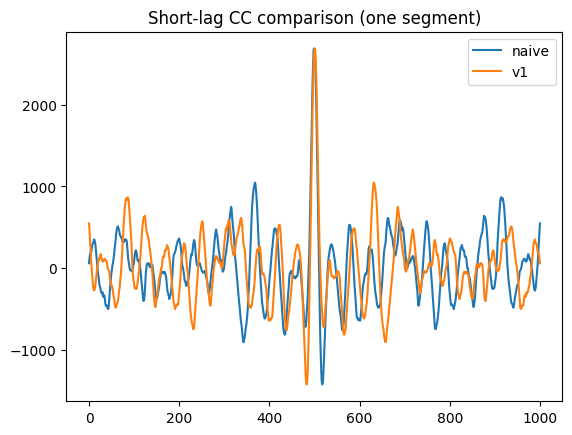

In [14]:
err = np.max(np.abs(cc_v1 - cc_naive))
print("max|v1 - naive| =", err)

plt.figure()
plt.plot(cc_naive, label="naive")
plt.plot(cc_v1, label="v1")
plt.legend()
plt.title("Short-lag CC comparison (one segment)")
plt.show()

#### 7. Zhang (2025) logic: explicitly construct `x_t` and `y_t` for ONE block

#### 7.1 Pick `K` and `Lfft` like the paper 

In [15]:
K, Lfft = choose_block_size_v2(M, fft_snap_pow2=True, fallback="v1_2M")
print("K:", K, "Lfft:", Lfft, "K+2M:", K+2*M)

K: 15384 Lfft: 16384 K+2M: 16384


#### 7.2 Pick block index l and build x_t, y_t

In [16]:
N = npts_seg
l = 0  # try 0, 1, 2...
start = l * K
end = min(start + K, N)
klen = end - start

x_t = torch.zeros((1, Lfft), dtype=torch.float32)
y_t = torch.zeros((1, Lfft), dtype=torch.float32)

# y_tilde placed at [M : M+klen]
y_t[:, M:M+klen] = yt[:, start:end]

# x window [start-M : start+K+M), clipped to [0,N)
x0 = start - M
x1 = start + K + M
ix0 = max(0, x0)
ix1 = min(N, x1)

if ix1 > ix0:
    dst0 = ix0 - x0
    dst1 = dst0 + (ix1 - ix0)
    x_t[:, dst0:dst1] = xt[:, ix0:ix1]

print("block l:", l, "start:", start, "end:", end, "klen:", klen)
print("x0,x1:", x0, x1, "ix0,ix1:", ix0, ix1)


block l: 0 start: 0 end: 15000 klen: 15000
x0,x1: -500 15884 ix0,ix1: 0 15000


In [19]:
def v1_blocks_time_domain_sum(xt: torch.Tensor, yt: torch.Tensor, M: int, K: int, Lfft: int) -> torch.Tensor:
    # xt, yt: (1, N)
    N = xt.shape[1]
    nblocks = int((N + K - 1) // K)
    rsum = torch.zeros((1, Lfft), dtype=torch.float32)

    for l in range(nblocks):
        start = l * K
        end = min(start + K, N)
        klen = end - start

        x_t = torch.zeros((1, Lfft), dtype=torch.float32)
        y_t = torch.zeros((1, Lfft), dtype=torch.float32)

        y_t[:, M:M+klen] = yt[:, start:end]

        x0 = start - M
        x1 = start + K + M
        ix0 = max(0, x0)
        ix1 = min(N, x1)
        if ix1 > ix0:
            dst0 = ix0 - x0
            dst1 = dst0 + (ix1 - ix0)
            x_t[:, dst0:dst1] = xt[:, ix0:ix1]

        X = torch.fft.rfft(x_t, n=Lfft, dim=-1)
        Y = torch.fft.rfft(y_t, n=Lfft, dim=-1)
        rsum += torch.fft.irfft(X.conj() * Y, n=Lfft, dim=-1)

    # extract [-M, M]
    out = torch.cat([rsum[:, Lfft-M:Lfft], rsum[:, :M+1]], dim=-1)
    return out

cc_blocks = v1_blocks_time_domain_sum(xt, yt, M, K, Lfft).squeeze().numpy()

print("max|blocks - v1| =", np.max(np.abs(cc_blocks - cc_v1)))
print("max|blocks - naive| =", np.max(np.abs(cc_blocks - cc_naive)))


max|blocks - v1| = 0.0
max|blocks - naive| = 1304.0


In [20]:
batch_len = 4
seg_idx0 = 0

# pick 4 receivers and use the first nseg segments
rcv0 = 0
rcvs = list(range(rcv0, rcv0+batch_len))

src_trace = data_proc[src_idx:src_idx+1, :]  # (1, npts_new)
full1 = np.repeat(src_trace, batch_len, axis=0)  # (batch_len, npts_new)
full2 = data_proc[rcvs, :]  # (batch_len, npts_new)

# reshape into (batch_len*nseg, npts_seg)
data1 = torch.from_numpy(full1).to(torch.float32).reshape(batch_len*nseg, npts_seg)
data2 = torch.from_numpy(full2).to(torch.float32).reshape(batch_len*nseg, npts_seg)

print("data1:", data1.shape, "data2:", data2.shape)

cc = cross_correlation_v1_real(data1, data2, max_lag_samples=M)  # (batch_len*nseg, 2M+1)
print("cc:", cc.shape)

cc_sum = cc.reshape(batch_len, nseg, -1).sum(dim=1)  # (batch_len, 2M+1)
print("cc_sum:", cc_sum.shape)


data1: torch.Size([40, 15000]) data2: torch.Size([40, 15000])
cc: torch.Size([40, 1001])
cc_sum: torch.Size([4, 1001])


In [21]:
import time
import torch

def crop_full_cc(cc_full, N, M):
    center = N - 1
    return cc_full[:, center - M : center + M + 1]

@torch.no_grad()
def bench_pair(model_conv_full, model_v1, x, y, N, M, nrep=20):
    # warmup
    for _ in range(5):
        _ = model_conv_full(x, y)
        _ = model_v1(x, y)

    is_cuda = (x.device.type == "cuda")
    if is_cuda:
        torch.cuda.synchronize()

    # conventional full -> crop
    t0 = time.perf_counter()
    for _ in range(nrep):
        cc_full = model_conv_full(x, y)          # (B, 2N-1)
        cc_crop = crop_full_cc(cc_full, N, M)    # (B, 2M+1)
    if is_cuda:
        torch.cuda.synchronize()
    t1 = time.perf_counter()

    # v1 short-lag
    for _ in range(nrep):
        cc_v1 = model_v1(x, y)                   # (B, 2M+1)
    if is_cuda:
        torch.cuda.synchronize()
    t2 = time.perf_counter()

    # final outputs for diff
    cc_full = model_conv_full(x, y)
    cc_crop = crop_full_cc(cc_full, N, M)
    cc_v1 = model_v1(x, y)

    diff = cc_crop - cc_v1
    max_abs = diff.abs().max().item()
    rel_l2 = diff.norm().item() / (cc_crop.norm().item() + 1e-12)

    return {
        "t_conv_full_crop": (t1 - t0) / nrep,
        "t_v1": (t2 - t1) / nrep,
        "speedup": ((t1 - t0) / nrep) / ((t2 - t1) / nrep),
        "max_abs": max_abs,
        "rel_l2": rel_l2,
    }
